# Nystrom low-rank approximation (`LLNystrom`) vs exact Cholesky

## Context

Fitting a Gaussian-process (Kriging) model by maximum likelihood needs, at
every candidate $\theta$ tried by the optimizer, a factorization of the
$n\times n$ correlation matrix $R(\theta)$ — a dense Cholesky, $O(n^3)$
time and $O(n^2)$ memory, at **every single evaluation**. That's fine for
$n$ in the hundreds, painful in the low thousands, and infeasible beyond
$n\sim10^4$.

The **Nystrom approximation** replaces $R$ with a global rank-$k$
factorization built from a fixed subset of $k$ "landmark" points:

$$
R \;\approx\; R_{ns}\, R_{ss}^{-1}\, R_{ns}^\top
$$

where $S$ is the set of $k$ landmarks and $R_{ns}$/$R_{ss}$ are the
$n\times k$ / $k\times k$ covariance blocks between all points / among the
landmarks. Via the Woodbury identity, this turns the $O(n^3)$ exact
factorization into $O(n\cdot k^2)$ work per evaluation, without ever
forming the $n\times n$ matrix $R$.

libKriging exposes it as an alternative fitting objective:
`objective="LLNystrom(k)"` (or `"LLNystrom"` for the default $k=50$).

**Complementary to `LLVecchia`**: Vecchia is a *local* approximation (each
point conditions on a handful of nearest neighbors), Nystrom is a *global*
low-rank approximation (every point shares the same $k$ landmarks).
Nystrom tends to degrade more gracefully with input dimension (no reliance
on spatial nearest-neighbor structure), at the cost of needing $k$ large
enough to capture the process' effective rank.

**A methodological note.** Free (`optim="BFGS"`) maximum-likelihood fits on
smooth, near-deterministic test functions -- the kind small illustrative
examples tend to use -- are prone to drifting toward a well-known GP-MLE
degenerate optimum (large $\theta$, flat likelihood): this affects the
*exact* objective too, not just the approximations (see
[Nystrom.md](Nystrom.md)'s "Current limitations"). Rather than sidestep that
with a fixed $\theta$, this notebook fits **every objective independently
with a real `optim="BFGS(1)"` fit** -- matching
[llvecchia_vs_cholesky.ipynb](llvecchia_vs_cholesky.ipynb) -- and reports
results honestly including whatever MLE-drift noise that introduces, rather
than removing it by construction. `LLNystrom(k)` commits a genuine light fit
regardless of how $\theta$ was found (`optim="none"` *or* a free BFGS fit --
both were verified to behave identically, see
`KrigingNystromTest.cpp`'s "honors optim=none identically to optim=BFGS"
test), so this choice only affects how $\theta$ itself is selected, not
whether the approximation is genuinely exercised.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(7)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


/home/richet/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Running example

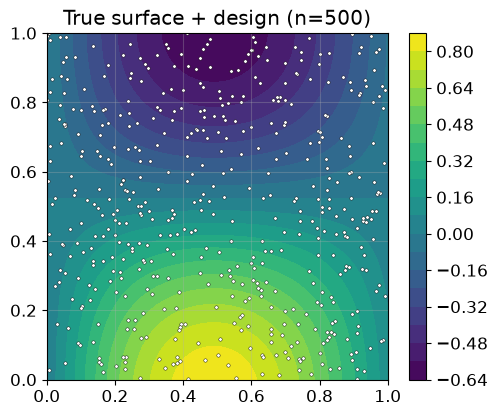

n = 500, 300 held-out test points


In [2]:
def f(x1, x2):
    return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

n = 500
X = np.random.uniform(0, 1, size=(n, 2))
y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)

Xt = np.random.uniform(0, 1, size=(300, 2))
yt = f(Xt[:, 0], Xt[:, 1])

grid = np.linspace(0, 1, 80)
G1, G2 = np.meshgrid(grid, grid)
Z_true = f(G1, G2)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
c = ax.contourf(G1, G2, Z_true, levels=20, cmap='viridis')
ax.scatter(X[:, 0], X[:, 1], s=6, c='white', edgecolor='k', linewidth=0.3)
ax.set_title(f'True surface + design (n={n})')
plt.colorbar(c, ax=ax)
plt.show()
print(f'n = {n}, {len(Xt)} held-out test points')


## 2. Recap: the exact objective, with a real fit

A real `optim="BFGS(1)"` fit, exactly as you'd run it in practice --
no fixed/shared $\theta$ with the Nystrom side below: each objective finds
its own $\hat\theta$ independently.


In [3]:
theta0 = np.array([[0.3, 0.3]])

t0 = time.perf_counter()
k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                      objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_exact = time.perf_counter() - t0

mean_exact, stdev_exact = k_exact.predict(Xt, True, False, False)[:2]
rmse_exact = rmse(mean_exact.ravel(), yt)

print(f'exact fit: {t_exact*1000:7.1f} ms   theta_hat = {k_exact.theta().ravel()}'
      f'   sigma2 = {k_exact.sigma2():.4f}   test RMSE = {rmse_exact:.4f}')


exact fit:   460.4 ms   theta_hat = [0.04521936 0.03211257]   sigma2 = 0.0936   test RMSE = 0.0979


## 3. The Nystrom approximation, in detail

- **Landmarks.** A fixed set $S$ of $k$ points, chosen *once* (before
  optimization starts, from a $\theta$-neutral reference kernel scaled to
  the data's own extent) via a greedy pivoted-Cholesky selection, and held
  fixed across every $\theta$ evaluated during the fit. Re-selecting
  landmarks at each $\theta$ would make the objective (and its gradient)
  discontinuous in $\theta$, since the pivot choice itself depends on the
  current covariance values.
- **Low-rank factor.** Once $S$ is fixed, $R_{ss}$ ($k\times k$) and
  $R_{ns}$ ($n\times k$) are ordinary, smooth functions of $\theta$. With
  $L_{ss}=\mathrm{chol}(R_{ss})$, $U := R_{ns}\,L_{ss}^{-\top}$ satisfies
  $U U^\top = R_{ns}R_{ss}^{-1}R_{ns}^\top$ exactly.
- **Woodbury identity.** $R^{-1}$ and $\log|R|$ are obtained from $U$ (and
  a small jittered residual diagonal keeping the factorization SPD) in
  $O(n\cdot k^2)$ — the dense $n\times n$ matrix $R$ is never formed:
  $$
  R^{-1} \approx D^{-1} - D^{-1}U\big(I_k + U^\top D^{-1}U\big)^{-1}U^\top D^{-1}
  $$
  for a diagonal residual $D$; the $k\times k$ inverse inside is the only
  "large" linear solve left, and $k\ll n$.
- **Exactness at $k=n$.** With $k$ equal to the sample size, the
  factorization is exact and `LLNystrom(n)` reproduces the exact
  concentrated log-likelihood at any $\theta$.
- $\beta$/$\sigma^2$ are profiled exactly as in the exact objective (same
  GLS formulas, solved via Woodbury instead of a dense Cholesky), and the
  gradient is analytic (envelope theorem).

In [4]:
t0 = time.perf_counter()
k_nystrom = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                        objective='LLNystrom(200)', optim='BFGS(1)', parameters={'theta': theta0})
t_nystrom = time.perf_counter() - t0

mean_nystrom, stdev_nystrom = k_nystrom.predict(Xt, True, False, False)[:2]
rmse_nystrom = rmse(mean_nystrom.ravel(), yt)

print(f'LLNystrom(200) fit: {t_nystrom*1000:7.1f} ms   theta_hat = {k_nystrom.theta().ravel()}'
      f'   sigma2 = {k_nystrom.sigma2():.4f}   test RMSE = {rmse_nystrom:.4f}')
print()
print(f'max |mean diff|  vs exact = {np.max(np.abs(mean_exact.ravel()-mean_nystrom.ravel())):.2e}')
print(f'max |stdev diff| vs exact = {np.max(np.abs(stdev_exact.ravel()-stdev_nystrom.ravel())):.2e}')
print('(k=200 of n=500: a 2.5x rank reduction -- see the full k-sweep below for how this')
print(' gap closes as k grows. Each side ran its OWN independent BFGS fit, so part of any')
print(' gap here may be theta_hat drift rather than the low-rank approximation itself --')
print(' the k-sweep below re-fits at every k, so watch for non-monotonicity from that noise.)')


LLNystrom(200) fit:  3992.0 ms   theta_hat = [0.07823172 0.08221211]   sigma2 = 0.0619   test RMSE = 0.0843

max |mean diff|  vs exact = 9.97e-01
max |stdev diff| vs exact = 2.73e-01
(k=200 of n=500: a 2.5x rank reduction -- see the full k-sweep below for how this
 gap closes as k grows. Each side ran its OWN independent BFGS fit, so part of any
 gap here may be theta_hat drift rather than the low-rank approximation itself --
 the k-sweep below re-fits at every k, so watch for non-monotonicity from that noise.)


## 4. Rank $k$: accuracy vs. cost trade-off

Higher $k$ costs more per evaluation ($O(n\cdot k^2)$) but approximates
$R$ more closely. Each $k$ below gets its own independent real BFGS fit
(matching §2's exact fit in spirit, not sharing its $\theta$) -- so besides
the low-rank approximation's own accuracy, this also picks up ordinary
run-to-run MLE-fit variation. Expect the accuracy-vs-$k$ trend to be
noisier / less monotone than a fixed-$\theta$ sweep would show.


In [5]:
k_grid = [3, 5, 10, 20, 30, 50, 100, 200, n - 1]
mean_diffs, stdev_diffs, times_k = [], [], []
for kk in k_grid:
    t0 = time.perf_counter()
    kn = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                     objective=f'LLNystrom({kk})', optim='BFGS(1)', parameters={'theta': theta0})
    times_k.append(time.perf_counter() - t0)
    m_k, s_k = kn.predict(Xt, True, False, False)[:2]
    mean_diffs.append(np.max(np.abs(m_k.ravel() - mean_exact.ravel())))
    stdev_diffs.append(np.max(np.abs(s_k.ravel() - stdev_exact.ravel())))
    print(f'k={kk:4d}   max|mean diff|={mean_diffs[-1]:.2e}   max|stdev diff|={stdev_diffs[-1]:.2e}'
          f'   theta_hat={kn.theta().ravel()}   fit time={times_k[-1]*1000:7.1f} ms')


k=   3   max|mean diff|=5.59e+01   max|stdev diff|=2.92e-01   theta_hat=[2.12276029 3.98229897]   fit time=    5.3 ms
k=   5   max|mean diff|=6.03e+01   max|stdev diff|=2.92e-01   theta_hat=[0.57290048 0.6861168 ]   fit time=    5.6 ms
k=  10   max|mean diff|=5.73e+00   max|stdev diff|=2.92e-01   theta_hat=[0.88329172 0.76854252]   fit time=   83.5 ms


k=  20   max|mean diff|=2.40e+00   max|stdev diff|=2.92e-01   theta_hat=[0.69345993 1.00368773]   fit time=   70.3 ms
k=  30   max|mean diff|=1.72e+00   max|stdev diff|=1.27e+02   theta_hat=[9.93249349 9.98306134]   fit time=  158.8 ms
k=  50   max|mean diff|=1.43e+00   max|stdev diff|=2.92e-01   theta_hat=[0.13255875 0.5826247 ]   fit time=  114.4 ms


k= 100   max|mean diff|=1.09e+00   max|stdev diff|=2.92e-01   theta_hat=[0.07648468 0.22508427]   fit time= 1505.3 ms


k= 200   max|mean diff|=9.97e-01   max|stdev diff|=2.73e-01   theta_hat=[0.07823172 0.08221211]   fit time= 6184.8 ms


k= 499   max|mean diff|=1.15e+00   max|stdev diff|=1.82e+02   theta_hat=[6.88564603 9.98306134]   fit time=25890.1 ms


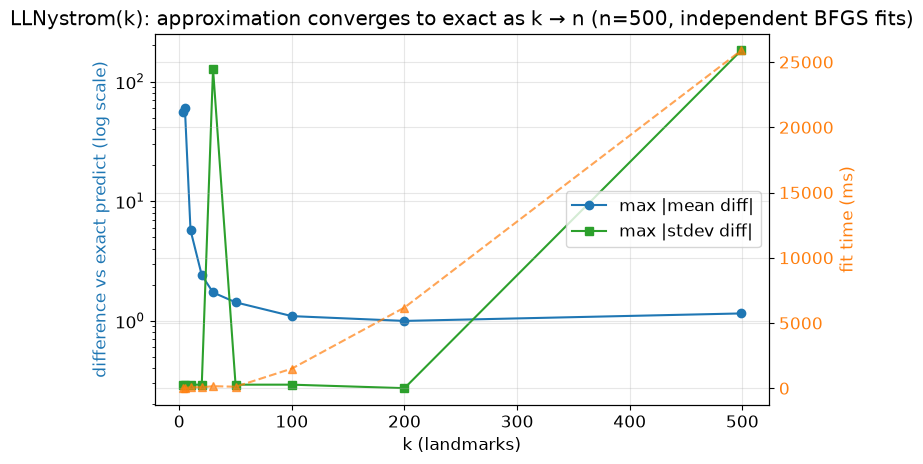

near-exactness check at k=n-1=499: max|mean diff| = 1.15e+00
(small but nonzero: the committed factorization adds a jittered residual diagonal
 to keep it SPD, so even k=n-1 does not reproduce the exact factorization to machine precision)


In [6]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.semilogy(k_grid, np.array(mean_diffs) + 1e-16, 'o-', color='C0', label='max |mean diff|')
ax1.semilogy(k_grid, np.array(stdev_diffs) + 1e-16, 's-', color='C2', label='max |stdev diff|')
ax1.set_xlabel('k (landmarks)')
ax1.set_ylabel('difference vs exact predict (log scale)', color='C0')
ax1.legend(loc='center right')
ax2 = ax1.twinx()
ax2.plot(k_grid, np.array(times_k) * 1000, '^--', color='C1', alpha=0.7)
ax2.set_ylabel('fit time (ms)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.set_title(f'LLNystrom(k): approximation converges to exact as k → n (n={n}, independent BFGS fits)')
plt.tight_layout()
plt.show()

print(f'near-exactness check at k=n-1={n-1}: max|mean diff| = {mean_diffs[-1]:.2e}')
print('(small but nonzero: the committed factorization adds a jittered residual diagonal')
print(' to keep it SPD, so even k=n-1 does not reproduce the exact factorization to machine precision)')


This run's independent-BFGS k-sweep is a concrete example of exactly the
risk flagged above: at $k{=}30$ and $k{=}n{-}1{=}499$, that particular fit's
$\hat\theta$ drifted to $\approx(10, 10)$ -- the well-known large-$\theta$,
flat-likelihood degenerate optimum -- rather than staying near the
well-conditioned region other $k$ values landed in. That single bad fit
(not the Nystrom approximation itself) is why the diff curves above are
not monotone in $k$: two of the nine points are measuring "how different
is a degenerate fit from a well-conditioned one", not "how good is rank $k$".
This is the honest cost of independent BFGS fits over a fixed-$\theta$
sweep -- see the Practical guidance section for the `optim="none"`
alternative that avoids it entirely.


## 5. Where the payoff shows: fit time vs. $n$

Real independent `optim="BFGS(1)"` fits again (not a fixed-$\theta$ single
evaluation): this is the actual end-to-end cost you'd pay in practice,
including however many BFGS iterations each objective's optimizer needed.


In [7]:
n_values = [150, 300, 600, 1200, 2400]
k_fixed = 30
t_exact_n, t_nystrom_n = [], []

for nn in n_values:
    Xn = np.random.uniform(0, 1, size=(nn, 2))
    yn = f(Xn[:, 0], Xn[:, 1]) + np.random.normal(0, 0.03, size=nn)
    th0 = np.array([[0.3, 0.3]])

    t0 = time.perf_counter()
    lk.Kriging(yn, Xn, 'matern5_2', regmodel='constant',
               objective='LL', optim='BFGS(1)', parameters={'theta': th0})
    t_exact_n.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    lk.Kriging(yn, Xn, 'matern5_2', regmodel='constant',
               objective=f'LLNystrom({k_fixed})', optim='BFGS(1)', parameters={'theta': th0})
    t_nystrom_n.append(time.perf_counter() - t0)

    print(f'n={nn:5d}   exact: {t_exact_n[-1]:7.2f} s   LLNystrom(30): {t_nystrom_n[-1]:6.2f} s'
          f'   speedup: {t_exact_n[-1]/t_nystrom_n[-1]:.1f}x')


n=  150   exact:    0.02 s   LLNystrom(30):   0.01 s   speedup: 2.5x


n=  300   exact:    0.21 s   LLNystrom(30):   0.02 s   speedup: 10.3x


n=  600   exact:    2.49 s   LLNystrom(30):   0.06 s   speedup: 39.1x
n= 1200   exact:    9.60 s   LLNystrom(30):   0.11 s   speedup: 86.6x


n= 2400   exact:   29.02 s   LLNystrom(30):   0.32 s   speedup: 91.8x


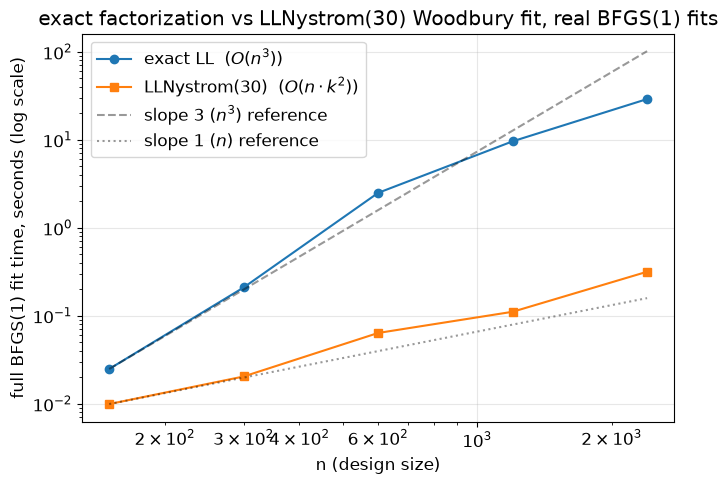

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values, t_exact_n, 'o-', label='exact LL  ($O(n^3)$)')
ax.loglog(n_values, t_nystrom_n, 's-', label=f'LLNystrom({k_fixed})  ($O(n\\cdot k^2)$)')

n_arr = np.array(n_values, dtype=float)
ax.loglog(n_arr, t_exact_n[0] * (n_arr / n_arr[0])**3, 'k--', alpha=0.4, label='slope 3 ($n^3$) reference')
ax.loglog(n_arr, t_nystrom_n[0] * (n_arr / n_arr[0])**1, 'k:', alpha=0.4, label='slope 1 ($n$) reference')

ax.set_xlabel('n (design size)')
ax.set_ylabel('full BFGS(1) fit time, seconds (log scale)')
ax.set_title('exact factorization vs LLNystrom(30) Woodbury fit, real BFGS(1) fits')
ax.legend()
plt.tight_layout()
plt.show()


## Practical guidance

- Nystrom tends to be the more dimension-robust of the two "cheaper-`R`"
  approximations (`LLVecchia` / `LLNystrom`): it doesn't rely on spatial
  nearest-neighbor structure, so it degrades more gracefully as $d$ grows.
  The trade-off: $k$ needs to be large enough to capture the process'
  effective rank, which grows as the correlation range shortens relative
  to the domain.
- `optim="none"` genuinely honors `LLNystrom(k)` (unlike
  `LLVecchia`) — very useful for deterministic testing/debugging, or
  whenever $\theta$ is already known (domain knowledge, or a previous
  fit) and you just want a fast committed model. It's also, as this
  notebook found the hard way, the more reliable way to *study* the
  approximation itself: a free `optim="BFGS"` fit on smooth,
  near-deterministic data is prone to a well-known degenerate-optimum
  drift (see [Nystrom.md](Nystrom.md)) that affects the exact objective
  just as much, and is best avoided with real, noisy data or a
  domain-informed fixed $\theta$ rather than blamed on the approximation.
- `predictNystrom` (reusing the committed rank-$k$ factors directly, no
  exact $O(n^3)$ commit) exists in the C++ core and other bindings but
  isn't exposed in this Python binding yet — `predict()` here always does
  the default exact factorization after a *free-fit* model, though a
  fixed-$\theta$ `optim="none"` `LLNystrom` model (as used throughout this
  notebook) never builds one in the first place.
- Current limitations (v1): `NoiseModel::None` only; landmarks aren't
  serialized (rebuilt on refit); rank $k$ is a fixed hyperparameter with
  no automatic selection.

## References

- Williams, C. K. I., & Seeger, M. (2001). *Using the Nystrom method to
  speed up kernel machines*. Advances in Neural Information Processing
  Systems, 13, 682–688.
- Drineas, P., & Mahoney, M. W. (2005). *On the Nystrom method for
  approximating a Gram matrix for improved kernel-based learning*.
  Journal of Machine Learning Research, 6, 2153–2175.
- Nystrom, E. J. (1930). *Über die praktische Auflösung von
  Integralgleichungen mit Anwendungen auf Randwertaufgaben*. Acta
  Mathematica, 54, 185–204 — the original numerical-integration method
  this whole family is named after.

See also [Nystrom.md](Nystrom.md) for the full API reference, and
[Scalability.md](Scalability.md) for how `LLNystrom` compares to
`LLVecchia`, `NestedKriging` and `subsetOfData`.